In [45]:
import mshr
import fenics
import dolfin
import numpy as np
import matplotlib.pyplot as plt
import copy
import pydmd
import pandas as pd
import time

# Problem statement

Consider the 2D nonlinear viscous Burgers' equation system for $u$ and $v$:
$$\partial_t u + u\partial_x u+v\partial_y u - \nu \Delta u = 0$$
$$\partial_t v + u\partial_x v + v\partial_y v - \nu \Delta v = 0$$
$$\Omega = [0;1]^2$$
$$0\le t\le 1$$
$$u(x, y, 0) = sin(\pi x)cos(\pi y) $$
$$v(x, y, 0) =  sin(\pi y)cos(\pi x)$$
$$u(0,y,t)=u(1,y,t)=v(x,0,t)=v(x,1,t)=0$$
Assume $\nu = 1e-2$.

Generate a uniform triangular grid in space and pick appropriate $\tau$ from convergence considerations. Apply the P1 finite element discretization in space and implicit Euler scheme in time, with the nonlinear problem being solved via Newton's method.

## Weak form

Let's consider the first equation:
$$\partial_t u + u\partial_x u+v\partial_y u - \nu \Delta u = 0$$
Multiply it by test function W and integrate over domain:
$$\int w\partial_t u + \int wu\partial_x u+\int wv\partial_y u - \int w\nu \Delta u = 0$$

Let's consider the term with laplacian

$$\int \nu w\Delta u = \int \nu\nabla\cdot(w\nabla u) - \int \nu \nabla w\cdot\nabla u =\int_\Gamma \nu w\nabla u \cdot n - \int \nu \nabla w\cdot\nabla u = - \int \nu \nabla w\cdot\nabla u$$

Because the test function is equal to zero on the boundaries.

Thus we obtain
$$\int w\frac{u-u^{prev}}{\tau} + \int wu\partial_x u+\int wv\partial_y u +\int \nu \nabla w\cdot\nabla u = 0$$
$$\int wu + \tau\int wu\partial_x u+\tau\int wv\partial_y u +\nu\tau\int \nabla w\cdot\nabla u = \int w u^{prev}$$

Therefore, the overall vectorised form reads:
$$\int w\cdot u + \tau\int w\cdot (u\nabla)u+\nu\tau\int \nabla w\cdot\nabla u = \int w\cdot u^{prev}$$

Similarly for the second equation we get

$$\int w\cdot v + \tau\int w\cdot (v\nabla)v+\nu\tau\int \nabla w\cdot\nabla v = \int w\cdot v^{prev}$$

To choose the appropriate time step we use the Courant-Friedrichs-Lewy condition:
$$C = \frac{u\tau}{h} \le  1$$

In [3]:
# boundary conditions
tol = 1E-14
def boundary_u(x, on_boundary):
    return on_boundary and (dolfin.near(x[0], 0, tol) or dolfin.near(x[0], 1, tol))

def boundary_v(x, on_boundary):
    return on_boundary and (dolfin.near(x[1], 0, tol) or dolfin.near(x[1], 1, tol))

In [4]:
def get_analyt_solution(mesh):
    xy_new = dolfin.SpatialCoordinate(mesh)
    Nmax = 30
    Mmax = 30
    t=1
    us1 = dolfin.Constant(0)
    us2 = dolfin.Constant(0)
    
    vs1 = dolfin.Constant(0)
    vs2 = dolfin.Constant(0)
    for n in range(Nmax):
        for m in range(Mmax):
            if n == 0 and m == 0:
                A = 1
            elif n == 0 and m != 0:
                A = 2
            elif n != 0 and m == 0:
                A = 2
            else:
                A = 4
            E = np.exp(-np.pi**2 * nu * t * (n**2 + m**2))
    
            if (n+m)%2 == 1:
                C = 0
            else:
                lamb = 1/(4*nu*np.pi)
                k1 = int((n+m)/2)
                k2 = int((n-m)/2)
    
                C = dolfin.bessel_I(k1, lamb)*dolfin.bessel_I(k2, lamb)
    
    
            us1 += n*A*E*C*dolfin.sin(n*np.pi*xy_new[0])*dolfin.cos(m*np.pi*xy_new[1])
            us2 += A*E*C*dolfin.cos(n*np.pi*xy_new[0])*dolfin.cos(m*np.pi*xy_new[1])
    
            vs1 += m*A*C*E*dolfin.cos(n*np.pi*xy_new[0])*dolfin.sin(m*np.pi*xy_new[1])
            vs2 += A*E*C*dolfin.cos(n*np.pi*xy_new[0])*dolfin.cos(m*np.pi*xy_new[1])
    
    u_comp = 2*np.pi*nu*us1/us2
    v_comp = 2*np.pi*nu*vs1/vs2
    
    V_ = dolfin.FunctionSpace(mesh, 'P', 1)
    trial_ = dolfin.TrialFunction(V_)
    test_ = dolfin.TestFunction(V_)
    L_ = u_comp*test_*dolfin.dx
    L_v = v_comp*test_*dolfin.dx
    A_ = trial_*test_*dolfin.dx
    u_ = dolfin.Function(V_)
    v_ = dolfin.Function(V_)
    dolfin.solve(A_ == L_, u_)
    dolfin.solve(A_ == L_v, v_)
    res = dolfin.Function(V)
    a_ = res.vector().get_local()
    a_[::2] = u_.vector().get_local()
    a_[1::2] = v_.vector().get_local()
    res.vector().set_local(a_)
    return res

In [65]:
ns = [10,50,100]
# ns = [100]
results = []
solution = []

data = 0

for n in ns:
    print("n = ", n)
    #mesh generation
    mesh = fenics.UnitSquareMesh(n, n, 'crossed')
    #functional space
    V = dolfin.VectorFunctionSpace(mesh, 'P', 1) 
    #physical constants
    nu = 1e-2
    # tau = hmin/umax, umax = 1
    tauCFL = mesh.hmin()
    #trial and test functions
    u = dolfin.TrialFunction(V)
    v = dolfin.TestFunction(V)
    u_prev = dolfin.Function(V)
    #weak form
    F = dolfin.dot(u, v)*dolfin.dx+tauCFL*dolfin.inner(dolfin.grad(u)*u, v)*dolfin.dx\
    +nu*tauCFL*dolfin.inner(dolfin.grad(u), dolfin.grad(v))*dolfin.dx-dolfin.inner(u_prev, v)*dolfin.dx
    u = dolfin.Function(V)
    F = dolfin.action(F, u) #turn bilinear form to linear acting on u
    J = dolfin.derivative(F, u)
    #initial condition
    inicond = dolfin.Expression(('sin(pi*x[0])*cos(pi*x[1])', 'sin(pi*x[1])*cos(pi*x[0])'), pi = np.pi, degree = 2)
    u_prev.interpolate(inicond)
    t = 0
    i = 0
    tmax = 1
    steps = np.ceil(tmax/tauCFL)
    data = np.zeros((V.dim(), int(steps)+1))
    data[:, 0] = copy.deepcopy(u_prev.vector().get_local())
    # boundary conditions
    bc0 = dolfin.DirichletBC(V.sub(0), dolfin.Constant(0.0), boundary_u)
    bc1 = dolfin.DirichletBC(V.sub(1), dolfin.Constant(0.0), boundary_v)
    bcs = [bc0, bc1]

    t2, t4, t6, t8 = 0, 0, 0, 0
    result = []

    # analyt = get_analyt_solution(mesh, u_comp, v_comp)
    analyt = get_analyt_solution(mesh)
    
    while t<1:
        print(t+tauCFL)
        t+=tauCFL
        dolfin.solve(F == 0, u, bcs,J = J)
        u_prev.assign(u)
        
        i+=1
        if t > 0.2 and t2 == 0:
            t2 = 1
            result.append(fenics.errornorm(u, analyt,'L2'))
        if t > 0.4 and t4 == 0:
            t4 = 1
            result.append(fenics.errornorm(u, analyt,'L2'))
        if t > 0.6 and t6 == 0:
            t6 = 1
            result.append(fenics.errornorm(u, analyt,'L2'))
        if t > 0.8 and t8 == 0:
            t8 = 1
            result.append(fenics.errornorm(u, analyt,'L2'))
        if n == 100:
            data[:, i] = copy.deepcopy(u_prev.vector().get_local())
    result.append(fenics.errornorm(u, analyt,'L2'))
    results.append(result)
    solution.append(u)
    
        

n =  10
0.09999999999999998
0.19999999999999996
0.29999999999999993
0.3999999999999999
0.4999999999999999
0.5999999999999999
0.6999999999999998
0.7999999999999998
0.8999999999999998
0.9999999999999998
1.0999999999999996
n =  50
0.019999999999999907
0.039999999999999813
0.05999999999999972
0.07999999999999963
0.09999999999999953
0.11999999999999944
0.13999999999999935
0.15999999999999925
0.17999999999999916
0.19999999999999907
0.21999999999999897
0.23999999999999888
0.2599999999999988
0.2799999999999987
0.2999999999999986
0.3199999999999985
0.3399999999999984
0.3599999999999983
0.37999999999999823
0.39999999999999813
0.41999999999999804
0.43999999999999795
0.45999999999999786
0.47999999999999776
0.49999999999999767
0.5199999999999976
0.5399999999999975
0.5599999999999974
0.5799999999999973
0.5999999999999972
0.6199999999999971
0.639999999999997
0.6599999999999969
0.6799999999999968
0.6999999999999967
0.7199999999999966
0.7399999999999965
0.7599999999999965
0.7799999999999964
0.799999999

In [66]:
table = pd.DataFrame(results, columns = [0.2, 0.4, 0.6, 0.8, 1], index = [10,50,100])
table

,0.2,0.4,0.6,0.8,1.0
10,0.271840,0.191561,0.117955,0.052279,0.012054
50,0.316925,0.229270,0.143824,0.064385,0.002052
100,0.323070,0.234794,0.147755,0.066077,0.000895


By increasing the grid size, the error between the computed solution and the theoretical solution decreases dramatically. 

Let's plot the solution with different resolution

Text(0.5, 1.0, 'u on grid 100x100')

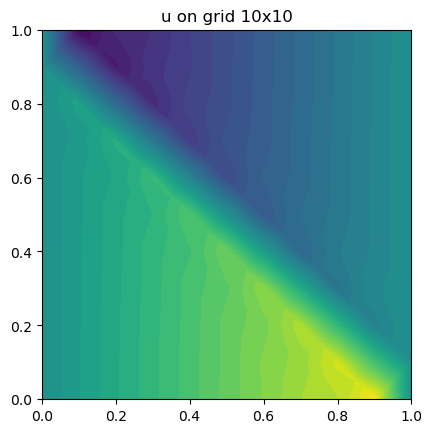

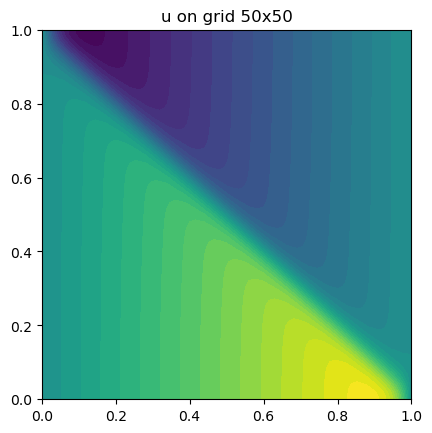

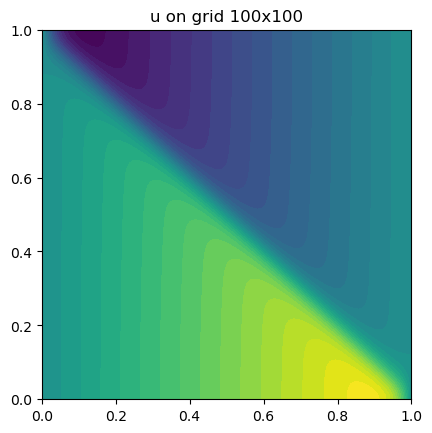

In [70]:
ux_10 = dolfin.dot(solution[0],dolfin.Expression(('1', '0'), degree = 1))
ux_50 = dolfin.dot(solution[1],dolfin.Expression(('1', '0'), degree = 1))
ux_100 = dolfin.dot(solution[2],dolfin.Expression(('1', '0'), degree = 1))

plt.figure()
fenics.plot(ux_10)
plt.title('u on grid 10x10')

plt.figure()
fenics.plot(ux_50)
plt.title('u on grid 50x50')

plt.figure()
fenics.plot(ux_100)
plt.title('u on grid 100x100')

# DMD

In [50]:
def quiverToL1(u):
    ux, uy = dolfin.dot(u,dolfin.Expression(('1', '0'), degree = 1)), dolfin.dot(u,dolfin.Expression(('0', '1'), degree = 1))
    return abs(ux)+abs(uy)

In [12]:
trainingSnapshots = data[:, :int(data.shape[1]/2)]
testingSnapshots = data[:, int(data.shape[1]/2):]

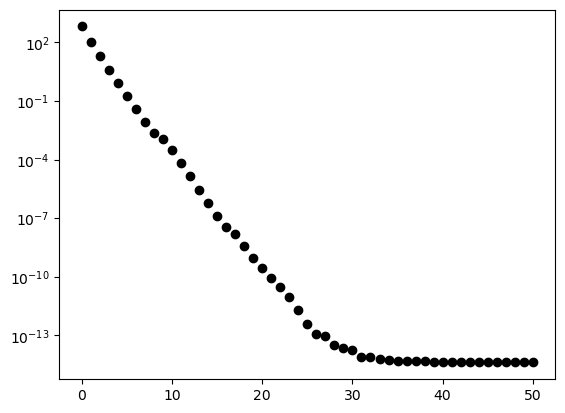

In [13]:
plt.semilogy(np.linalg.svd(trainingSnapshots, compute_uv = False), "ko")

In [14]:
#helper to plot nparray
def npArrayToFunction(u,V):
    _ = dolfin.Function(V)
    _.vector().set_local(u)
    return _

In [62]:
ranks = [3,5,10,15,20]
errors = []
times = []

for rank in ranks:
    t = []
    for i in range(40):
        t0 = time.perf_counter()
        dmd = pydmd.DMD(svd_rank = rank, opt = True)
        dmd.fit(trainingSnapshots)
        dmd.dmd_time["tend"] *= 2
        t.append(time.perf_counter()-t0)
    times.append(np.mean(t))
    data_dmd = dmd.reconstructed_data[:, 50:]
    err = np.linalg.norm(data_dmd-testingSnapshots, 2, 0)
    errors.append(err[9::10]) # 0.6, 0.7, 0.8, 0.9, 1 s

/home/daria/.local/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.5971655833993414e+17. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [64]:
table_dmd = pd.DataFrame(errors, index = [3,5,10,15,20], columns = [0.6,0.7,0.8,0.9,1])
table_dmd['CPU time'] = times
table_dmd

,0.6,0.7,0.8,0.9,1.0,CPU time
3,2.231013,3.783032,5.115838,6.156833,6.897170,0.453366
5,0.884786,1.361873,2.145469,3.070016,4.009506,0.436252
10,0.769534,1.104899,1.800359,2.626188,3.505797,0.466818
15,0.749599,0.999729,1.667247,2.468860,3.328741,0.486533
20,1.010283,0.882738,0.948496,1.326231,1.921013,0.475083


As we can see the error decreases as the rank increases. It is obvious, because by increasing the rank we increase the number of used eigenvalues and eigenvalues and thus increase presicion of decomposition. But while the rank increases, the execution time also increases due to increased number of operations.

/tmp/ipykernel_8428/3491492245.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  _.vector().set_local(u)


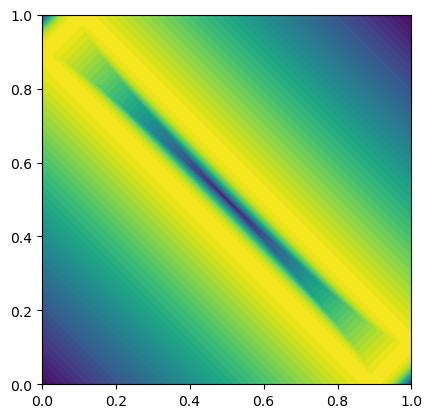

In [58]:
fenics.plot(quiverToL1(npArrayToFunction(data_dmd[:, -1], V)))

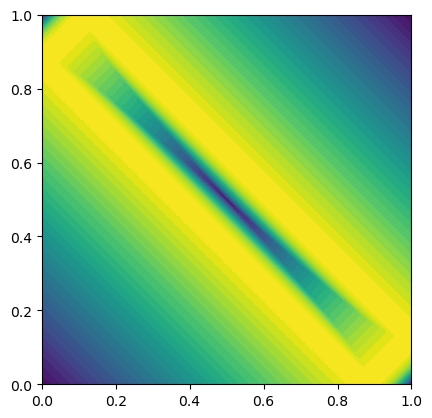

In [57]:
fenics.plot(quiverToL1(npArrayToFunction(testingSnapshots[:, -1], V)))

As we can see from the l2 norm and from the plots of the solution, the dmd approximates the solution very good.